# **Support Vector Classifier Implementation (SVC)**

In [418]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Creating Synthetic data points

In [419]:
from sklearn.datasets import make_classification

In [420]:
X,y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_clusters_per_class=1,n_redundant=0)

In [421]:
X

array([[-0.95862469, -2.88548767],
       [-1.3381811 , -0.89807253],
       [-2.50770276, -0.30633063],
       ...,
       [-0.84230499, -1.47091282],
       [-1.17152373,  0.09373615],
       [ 0.6766401 , -0.84070574]])

In [422]:
y

array([0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,

In [423]:
pd.DataFrame(X)[0]


0     -0.958625
1     -1.338181
2     -2.507703
3      1.397970
4     -0.318847
         ...   
995    0.653031
996   -1.485804
997   -0.842305
998   -1.171524
999    0.676640
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='Feature1', ylabel='Feature2'>

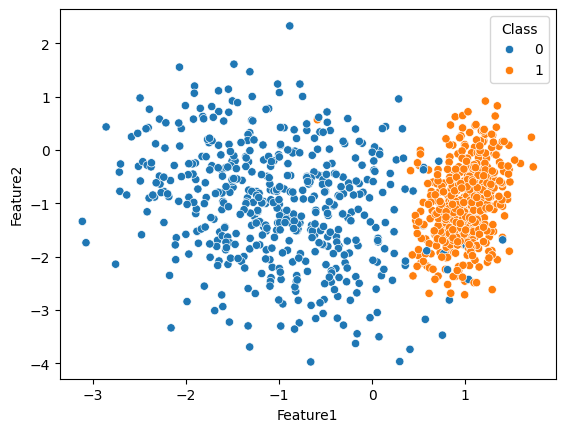

In [424]:
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df['Class'] = y

sns.scatterplot(
    data=df,
    x='Feature1',
    y='Feature2',
    hue='Class'
)

### Types of sepration of data points
here data points are seprated Non - Linear , so i used **RBF kernel** beacuse it can map the data into a higher dimensional space where the classes beacome linearly seprable.

In [425]:
from sklearn.svm import SVC

## Using RBF kernel

In [426]:
rbf = SVC(kernel = 'rbf')

#### Training the model

In [427]:
from sklearn.model_selection import train_test_split

In [428]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=10)

In [429]:
rbf.fit(X_train, y_train)

SVC()

#### Prediction

In [430]:
y_pred=rbf.predict(X_test)

### Performance matrics

In [431]:
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix

In [432]:
score = accuracy_score(y_test,y_pred)
print("Score:",score)
cm = confusion_matrix(y_test,y_pred)
print("confusion matrix:\n",cm)
cr = classification_report(y_test,y_pred)
print("Classification Report:\n",cr)

Score: 0.992
confusion matrix:
 [[123   2]
 [  0 125]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       125
           1       0.98      1.00      0.99       125

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250



## Using Linear Kernel

In [433]:
svc = SVC(kernel = 'linear')
svc.fit(X_train, y_train)
y_pred=svc.predict(X_test)

In [434]:
score = accuracy_score(y_test,y_pred)
print("Score:",score)
cm = confusion_matrix(y_test,y_pred)
print("confusion matrix:\n",cm)
cr = classification_report(y_test,y_pred)
print("Classification Report:\n",cr)

Score: 0.988
confusion matrix:
 [[122   3]
 [  0 125]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       125
           1       0.98      1.00      0.99       125

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250



## Using Polynomial kernel

In [435]:
poly = SVC(kernel = 'poly')
poly.fit(X_train, y_train)
y_pred=poly.predict(X_test)

In [436]:
score = accuracy_score(y_test,y_pred)
print("Score:",score)
cm = confusion_matrix(y_test,y_pred)
print("confusion matrix:\n",cm)
cr = classification_report(y_test,y_pred)
print("Classification Report:\n",cr)

Score: 0.988
confusion matrix:
 [[123   2]
 [  1 124]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       125
           1       0.98      0.99      0.99       125

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250



## Using sigmoid kernel

In [437]:
sigmoid = SVC(kernel = 'sigmoid')
sigmoid.fit(X_train, y_train)
y_pred=sigmoid.predict(X_test)

In [438]:
score = accuracy_score(y_test,y_pred)
print("Score:",score)
cm = confusion_matrix(y_test,y_pred)
print("confusion matrix:\n",cm)
cr = classification_report(y_test,y_pred)
print("Classification Report:\n",cr)

Score: 0.928
confusion matrix:
 [[119   6]
 [ 12 113]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       125
           1       0.95      0.90      0.93       125

    accuracy                           0.93       250
   macro avg       0.93      0.93      0.93       250
weighted avg       0.93      0.93      0.93       250



### Hyperparameter Tuning with SVC

In [439]:
from sklearn.model_selection import GridSearchCV

In [440]:
param_grid={
    'C':[0.1,1,10,100,1000],
    'gamma':[1,0.1,0.01,0.001,0.0001],
    'kernel':['rbf']}

In [441]:
grid=GridSearchCV(SVC(),param_grid=param_grid, cv=5, verbose=3, refit=True)

In [442]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.987 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.987 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.973 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.967 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.953 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.927 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [443]:
grid.best_params_

{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}

In [445]:
y_pred_grid=grid.predict(X_test)
score = accuracy_score(y_test,y_pred_grid)
print("Score:",score)
cm = confusion_matrix(y_test,y_pred_grid)
print("confusion matrix:\n",cm)
cr = classification_report(y_test,y_pred_grid)
print("Classification Report:\n",cr)

Score: 0.992
confusion matrix:
 [[123   2]
 [  0 125]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       125
           1       0.98      1.00      0.99       125

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250

